In [5]:
import torch
import torch.utils.data
from torch import nn
from model.egno import EGNO
from motion.dataset import MotionDynamicsDataset as MotionDataset
import random
import numpy as np

seed = 1
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

device="cuda"

model = EGNO(
    n_layers=6, 
    in_node_nf=2, 
    in_edge_nf=2, 
    hidden_nf=128,
    device=device,
    with_v=True,
    activation=nn.SiLU(),
    use_time_conv=True,
    num_modes=2,
    num_timesteps=5,
    time_emb_dim=32
)

model_weights = "log/mocap_exp/saved_model.pth"

model.load_state_dict(torch.load(model_weights, map_location=device))
model.eval()

EGNO(
  (layers): ModuleList(
    (0-5): 6 x EGNN_Layer(
      (edge_message_net): InvariantScalarNet(
        (activation): SiLU()
        (scalar_net): BaseMLP(
          (mlp): Sequential(
            (0): Linear(in_features=259, out_features=128, bias=True)
            (1): SiLU()
            (2): Linear(in_features=128, out_features=128, bias=True)
            (3): SiLU()
          )
        )
      )
      (coord_net): BaseMLP(
        (mlp): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): SiLU()
          (2): Linear(in_features=128, out_features=1, bias=True)
        )
      )
      (node_v_net): BaseMLP(
        (mlp): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): SiLU()
          (2): Linear(in_features=128, out_features=1, bias=True)
        )
      )
      (node_net): BaseMLP(
        (mlp): Sequential(
          (0): Linear(in_features=256, out_features=128, bias=True)
         

In [6]:
data_dir = "motion/dataset"
delta_frame = 30
max_training_samples = 30
num_timesteps = 5
case="walk"
batch_size=12

dataset_train = MotionDataset(partition='train', max_samples=max_training_samples, data_dir=data_dir,
                                delta_frame=delta_frame, case=case, num_timesteps=num_timesteps)
loader_train = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, drop_last=True,
                                            num_workers=0)

dataset_val = MotionDataset(partition='val', max_samples=600, data_dir=data_dir,
                            delta_frame=delta_frame, case=case, num_timesteps=num_timesteps)
loader_val = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, drop_last=False,
                                            num_workers=0)

dataset_test = MotionDataset(partition='test', max_samples=600, data_dir=data_dir,
                                delta_frame=delta_frame, case=case, num_timesteps=num_timesteps)
loader_test = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, drop_last=False,
                                            num_workers=0)


Got Split!
Got 22 samples!
Got Split!
Got 600 samples!
Got Split!
Got 600 samples!


| # | Tensor | Shape | What it is |
|---|--------|-------|------------|
| 1 | `x_0` | `[12, 31, 3]` | Starting positions of each joint at frame_0 (coords like (0.1, 18.0, 2.69) — body in world space) |
| 2 | `v_0` | `[12, 31, 3]` | Starting velocities at frame_0 (small magnitudes, ~0.01–0.4) |
| 3 | `edges` | `[12, 2, E]` | All edges as [rows, cols] index pairs; type=1 (local skeleton) + type=2 (non-local). E.g. (0,1), (0,2), …, (30,28) |
| 4 | `edge_attr` | `[12, E, 1]` | Edge labels — 1=local bone, 2=non-local |
| 5 | `local_edges` | `[12, 2, E_local]` | Subset of edges where label==1 (skeleton bones only) |
| 6 | `local_edge_attr` | `[12, E_local, 1]` | All 1s — labels for local_edges |
| 7 | `node_fea` | `[12, 31, 1]` | Scalar node feature: `x_0[..., 1] / 10` (y-coord ÷ 10 — sanity check: tensor 1's `x_0[0,0,1]` = 18.01 → 1.8011 ✓) |
| 8 | `x_t` | `[12, 31, 5, 3]` | Target positions at 5 future timesteps (your `loc_end`) |
| 9 | `v_t` | `[12, 31, 5, 3]` | Target velocities at 5 future timesteps |


In [32]:
num_timesteps = 5  # match model

all_pred, all_true, all_x0 = [], [], []

with torch.no_grad():
    for data in loader_test:
        batch_size, n_nodes, _ = data[0].size()
        data = [d.to(device) for d in data]
        x0 = data[0].clone()  # [B, N, 3] starting positions

        # reshape targets: [B, N, T, 3] -> [T*B*N, 3]
        for i in [-1, -2]:
            d = data[i].view(batch_size * n_nodes, num_timesteps, 3)
            data[i] = d.transpose(0, 1).contiguous().view(-1, 3)

        loc, vel, edges, edge_attr, local_edges, local_edge_fea, Z, loc_end, vel_end = data

        loc_mean = loc.mean(dim=1, keepdim=True).repeat(1, n_nodes, 1).view(-1, loc.size(2))
        loc = loc.view(-1, loc.size(2))
        vel = vel.view(-1, vel.size(2))

        offset = (torch.arange(batch_size) * n_nodes).unsqueeze(-1).unsqueeze(-1).to(edges.device)
        edges = torch.cat(list(edges + offset), dim=-1)
        edge_attr = torch.cat(list(edge_attr), dim=0)
        Z = Z.view(-1, Z.size(2))

        nodes = torch.sqrt(torch.sum(vel ** 2, dim=1)).unsqueeze(1)
        nodes = torch.cat((nodes, Z / Z.max()), dim=-1)
        rows, cols = edges
        loc_dist = torch.sum((loc[rows] - loc[cols]) ** 2, 1).unsqueeze(1)
        edge_attr = torch.cat([edge_attr, loc_dist], 1)

        loc_pred, vel_pred, _ = model(loc, nodes, edges, edge_attr,
                                       v=vel, loc_mean=loc_mean)

        # [T*B*N, 3] -> [B, T, N, 3]
        pred = loc_pred.view(num_timesteps, batch_size, n_nodes, 3).permute(1, 0, 2, 3).cpu()
        true = loc_end.view(num_timesteps, batch_size, n_nodes, 3).permute(1, 0, 2, 3).cpu()
        all_pred.append(pred)
        all_true.append(true)
        all_x0.append(x0.cpu())

all_pred = torch.cat(all_pred, dim=0).numpy()   # [num_samples, T, N, 3]
all_true = torch.cat(all_true, dim=0).numpy()   # [num_samples, T, N, 3]
all_x0   = torch.cat(all_x0,   dim=0).numpy()   # [num_samples, N, 3]

print(all_pred.shape, all_true.shape, all_x0.shape)

(600, 5, 31, 3) (600, 5, 31, 3) (600, 31, 3)


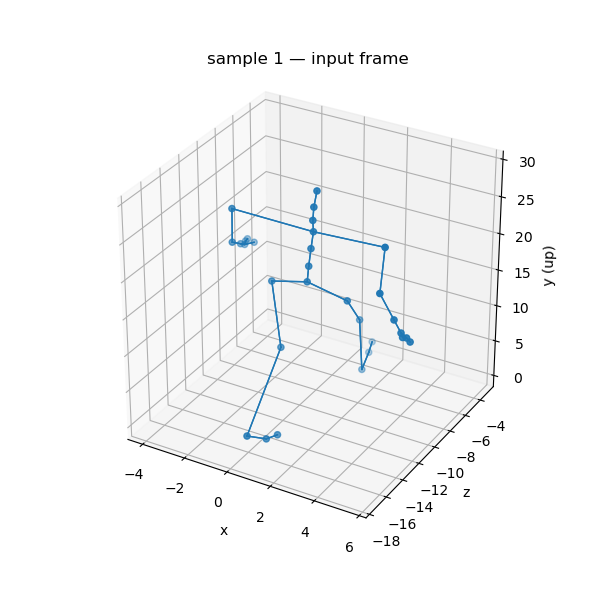

In [41]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

%matplotlib widget

sample = 1
joints = all_x0[sample]    # (31, 3) — starting frame of one test sample

# skeleton bones from the dataset
ds_edges = loader_test.dataset.edges.numpy()
ds_attr  = loader_test.dataset.edge_attr.numpy()
bones = ds_edges[:, ds_attr[:, 0] == 1].T

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

# data is (x, y_up, z) — matplotlib wants (x, z, y) so y_up points up on screen
xs, ys, zs = joints[:, 0], joints[:, 2], joints[:, 1]
ax.scatter(xs, ys, zs, c='tab:blue', s=20)
for i, j in bones:
    ax.plot(joints[[i, j], 0], joints[[i, j], 2], joints[[i, j], 1], c='tab:blue', lw=1)

ax.set_xlabel('x'); ax.set_ylabel('z'); ax.set_zlabel('y (up)')
ax.set_title(f'sample {sample} — input frame')
ax.set_box_aspect((1, 1, 1))
plt.show()


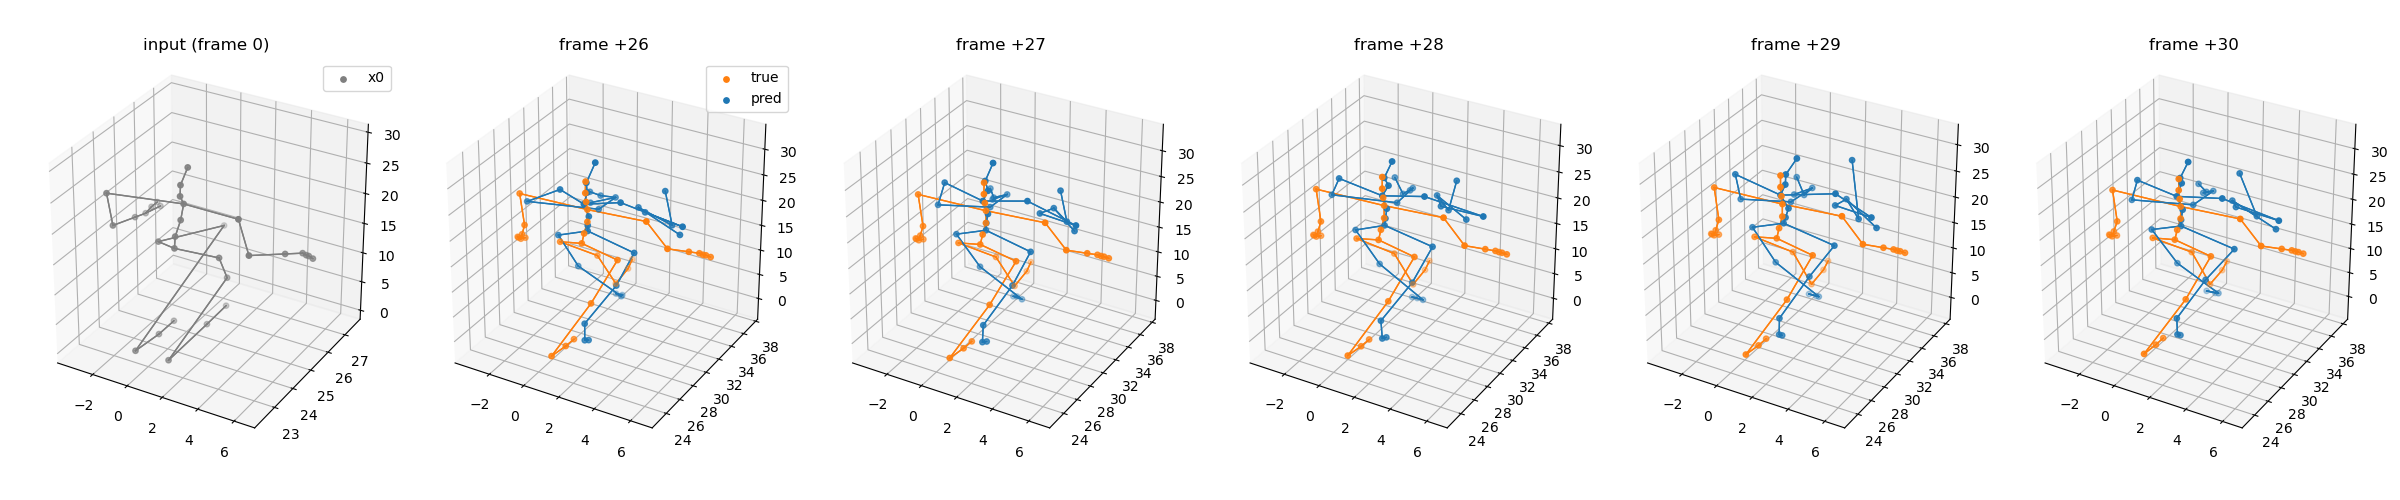

In [43]:
sample = 500
x0   = all_x0[sample]      # (31, 3)
pred = all_pred[sample]    # (5, 31, 3)
true = all_true[sample]    # (5, 31, 3)

bones = ds_edges[:, ds_attr[:, 0] == 1].T

def draw(ax, j, color, label=None):
    ax.scatter(j[:, 0], j[:, 2], j[:, 1], c=color, s=15, label=label)
    for a, b in bones:
        ax.plot(j[[a, b], 0], j[[a, b], 2], j[[a, b], 1], c=color, lw=1)

fig = plt.figure(figsize=(24, 5))
ax = fig.add_subplot(1, 6, 1, projection='3d')
draw(ax, x0, 'tab:gray', 'x0')
ax.set_title('input (frame 0)'); ax.set_box_aspect((1, 1, 1)); ax.legend()

for t in range(5):
    ax = fig.add_subplot(1, 6, t + 2, projection='3d')
    draw(ax, true[t], 'tab:orange', 'true' if t == 0 else None)
    draw(ax, pred[t], 'tab:blue',   'pred' if t == 0 else None)
    ax.set_title(f'frame +{26 + t}'); ax.set_box_aspect((1, 1, 1))
    if t == 0:
        ax.legend()

plt.tight_layout(); plt.show()
